<a href="https://colab.research.google.com/github/Yashgupta-01/Churn-prediction/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import data from Telecom churn prediction folder in my drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/Telecom churn prediction/data/raw/telecom_churn.csv'
data = pd.read_csv(file_path, low_memory=False)

In [ ]:
# 2. Clean column names
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
# 3. Quick data overview
print("First 5 rows:\n", data.head())

First 5 rows:
    customer_id telecom_partner gender  age              state     city  \
0            1    Reliance Jio      F   25          Karnataka  Kolkata   
1            2    Reliance Jio      F   55            Mizoram   Mumbai   
2            3        Vodafone      F   57  Arunachal Pradesh    Delhi   
3            4            BSNL      M   46         Tamil Nadu  Kolkata   
4            5            BSNL      F   26            Tripura    Delhi   

   pincode date_of_registration  num_dependents  estimated_salary  calls_made  \
0   755597           2020-01-01               4            124962          44   
1   125926           2020-01-01               2            130556          62   
2   423976           2020-01-01               0            148828          49   
3   522841           2020-01-01               1             38722          80   
4   740247           2020-01-01               2             55098          78   

   sms_sent  data_used  churn  
0        45       -36

In [ ]:
print("\nSummary Statistics:\n", data.describe(include='all'))
print("\nDataFrame Info:\n")
data.info()


Summary Statistics:
           customer_id telecom_partner  gender            age        state  \
count   243553.000000          243553  243553  243553.000000       243553   
unique            NaN               4       2            NaN           28   
top               NaN    Reliance Jio       M            NaN  Uttarakhand   
freq              NaN           61123  145977            NaN         8856   
mean    121777.000000             NaN     NaN      46.077609          NaN   
std      70307.839393             NaN     NaN      16.444029          NaN   
min          1.000000             NaN     NaN      18.000000          NaN   
25%      60889.000000             NaN     NaN      32.000000          NaN   
50%     121777.000000             NaN     NaN      46.000000          NaN   
75%     182665.000000             NaN     NaN      60.000000          NaN   
max     243553.000000             NaN     NaN      74.000000          NaN   

           city        pincode date_of_registration  

In [ ]:
print("\nMissing values per column:\n", data.isnull().sum())
data = data.drop_duplicates()


Missing values per column:
 customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64


In [ ]:

# 5. Optimize data types for memory
for col in data.select_dtypes(include=['float64']).columns:
    data[col] = data[col].astype('float32')
for col in data.select_dtypes(include=['int64']).columns:
    data[col] = data[col].astype('int32')

In [ ]:
# 6. Feature engineering (dates, etc.)
if 'date_of_registration' in data.columns:
    data['date_of_registration'] = pd.to_datetime(data['date_of_registration'], errors='coerce')

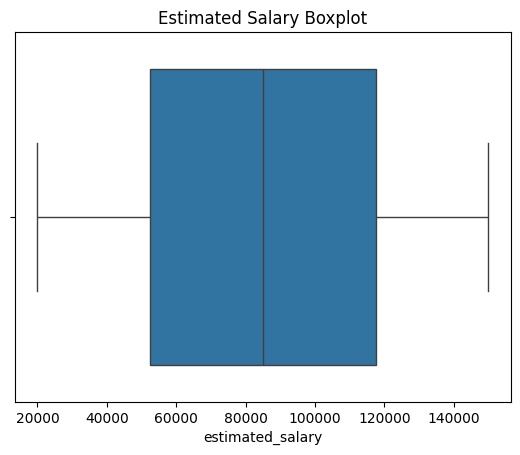

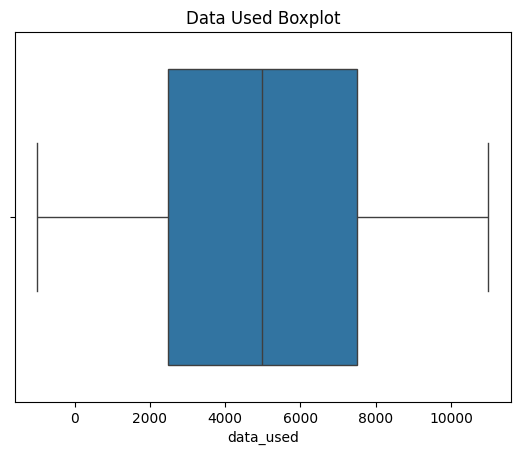

In [ ]:

# 7. Visualize outliers (optional)
if 'estimated_salary' in data.columns:
    sns.boxplot(x=data['estimated_salary'])
    plt.title('Estimated Salary Boxplot')
    plt.show()
if 'data_used' in data.columns:
    sns.boxplot(x=data['data_used'])
    plt.title('Data Used Boxplot')
    plt.show()

In [ ]:

# 8. Encode categorical variables
categorical_cols = ['telecom_partner', 'gender', 'state', 'city']
for col in categorical_cols:
    if col in data.columns:
        data[col] = data[col].astype('category')
data = pd.get_dummies(data, columns=[col for col in categorical_cols if col in data.columns], drop_first=True)

In [ ]:

# 9. Scale numerical features
from sklearn.preprocessing import StandardScaler
numerical_cols = [col for col in ['age', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used'] if col in data.columns]
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

Churn Value Counts:
 churn
0    194726
1     48827
Name: count, dtype: int64


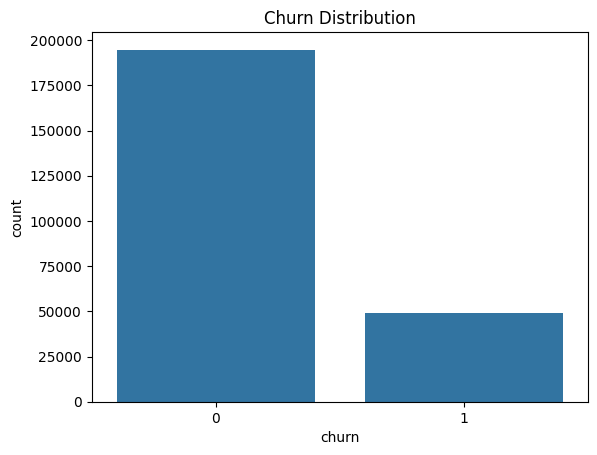

Churn Rate: 20.05%


In [ ]:

# 10. Churn distribution
if 'churn' in data.columns:
    print("Churn Value Counts:\n", data['churn'].value_counts())
    sns.countplot(x='churn', data=data)
    plt.title('Churn Distribution')
    plt.show()
    print(f"Churn Rate: {data['churn'].mean():.2%}")

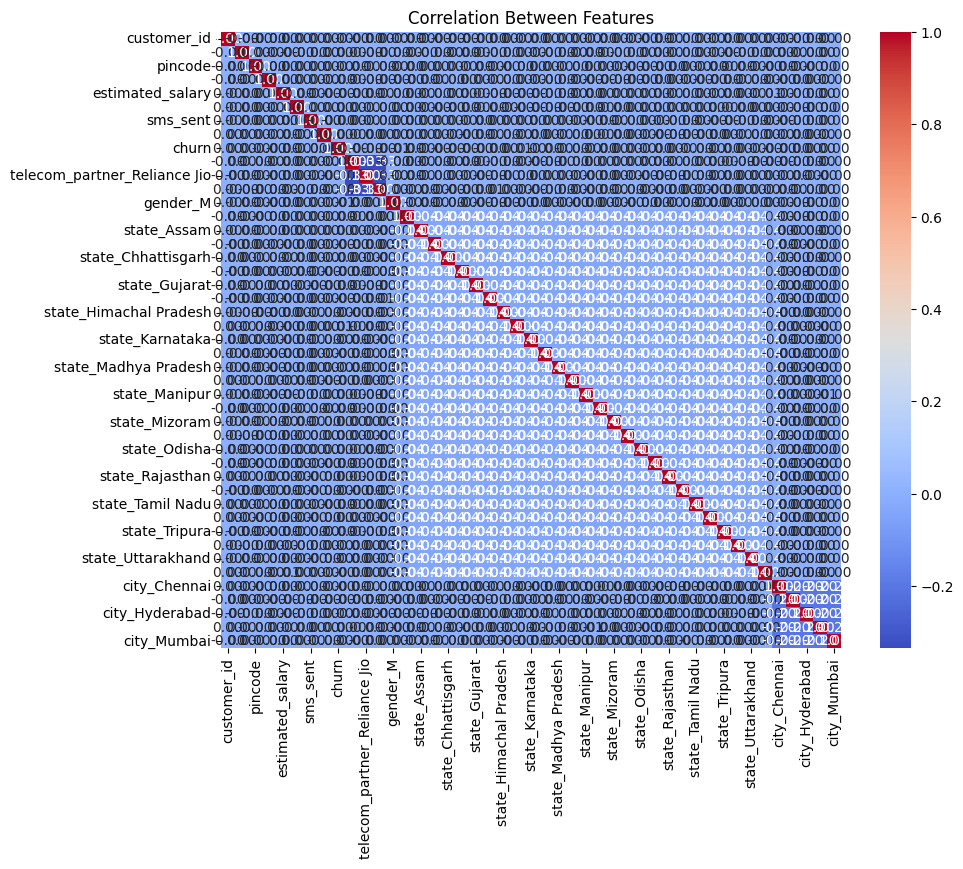

In [ ]:
# 11. Correlation analysis
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Between Features')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# 12. Train-test split
X = data.drop(columns=[col for col in ['customer_id', 'churn'] if col in data.columns])
y = data['churn'] if 'churn' in data.columns else None
if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

    # 13. Save processed data
    X_train.to_csv('/content/drive/MyDrive/Telecom churn prediction/data/processed/X_train.csv', index=False)
    X_test.to_csv('/content/drive/MyDrive/Telecom churn prediction/data/processed/X_test.csv', index=False)
    y_train.to_csv('/content/drive/MyDrive/Telecom churn prediction/data/processed/y_train.csv', index=False)
    y_test.to_csv('/content/drive/MyDrive/Telecom churn prediction/data/processed/y_test.csv', index=False)

Train shape: (170487, 44) Test shape: (73066, 44)
